# 📊 Model Evaluation
Evaluate heuristic baseline model, all base models, and all ensemble models using recall@5 (primary metric), ndcg@5, precision@5, and F1@5 for validation and test splits. Identify feature importance using mean absolute SHAP bar plots and SHAP feature importance beeswarm plots. Save data for Power BI dashboard to Big Query.

### Overview
1. Imports & Setup
2. Define Model & Feature Name Mapping
3. Load Data, Base Models, and Optimal Ensemble Weights
4. Evaluate Models (Recall@5, precision@5, F1@5, NDCG@5
5. Get Evaluation Metric Barplots
6. Create SHAP Plots
7. Get Sample Data for Power BI Beeswarm Plots
8. Get Optimal Ensemble Weights for Power BI Pie Chart
9. Orchestration

In [1]:
#Set sys path to ensure python can find utilities
%matplotlib inline

import sys
import os
import warnings

import pandas as pd
import numpy as np
import pickle
import json
import gcsfs
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import lightgbm as lgb
import bigframes.pandas as bpd
from google.cloud import bigquery
from sklearn.metrics import ndcg_score

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

from config.config import BUCKET_NAME, BUCKET_PATH, project_id, source_loc, output_loc, config_loc, results_dataset

sys.path.insert(0, source_loc)
from utilities.utility_functions import (get_bq_data_full, select_features, split_data, compute_rrf_scores, calculate_metrics_at_k, get_baseline_evaluation_metrics,
                                        process_order, calculate_ndcg_at_k)

#Suppress warnings to ensure clean notebook
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

pd.options.mode.chained_assignment = None

In [2]:
fs = gcsfs.GCSFileSystem()

### Define Model & Featur Name Mapping

In [5]:
model_mapping = {
                'lgbm_classifier_base_model': 'LightGBM Classifier',
                'xgboost_classifier_base_model': 'XGBoost Classifier',
                'lgbm_ranker_base_model': 'LightGBM Ranker',
                'xgboost_ranker_base_model': 'XGBoost Ranker',
                'ens1_lgb_rank_xgb_class': 'LightGBM Ranker + XGBoost Classifier',
                'ens2_lgb_rank_lgb_class': 'LightGBM Ranker + LightGBM Classifier',
                'ens3_xgb_rank_lgb_class': 'XGBoost Ranker + LightGBM Classifier',
                'ens4_xgb_rank_xgb_class': 'XGBoost Ranker + XGBoost Classifier',
                'ens5_all_base_models': 'Full Ensemble (All Base Models)'}

feature_display_mapping = {
                "user_prod_avg_days_between_purchases": "Avg Days Between Product Purchases",
                "user_product_consecutive_order_skips": "Consecutive Product Order Skips",
                "label_user_product_days_since_last_purchased": "Days Since Last Purchase",
                "user_product_reorder_concentration": "Product Reorder Concentration",
                "user_product_purchase_concentration": "Product Purchase Concentration",
                "user_reorder_ratio": "User Reorder Rate",
                "user_deptartment_share": "Department Share of Order History",
                "user_product_nearing_reorder_ratio": "Nearing Reorder Threshold Ratio",
                "user_product_avg_cart_position": "Avg Cart Position",
                "user_product_order_penetration_ratio": "Product Order Penetration Rate",
                "user_product_cumulative_purchases": "Cumulative Product Purchases",
                "user_product_last3order_streak": "Last 3 Orders Purchase Streak",
                "user_distinct_product_count": "Distinct Product Count",
                "user_product_cart_position_last_order": "Last Order Cart Position",
                "user_aisle_share": "Aisle Share of Order History"}


### Load Data, Base Models, & Optimal Ensemble Weights

In [6]:
def load_data_models_weights():
    """
    Loads features data from BigQuery, creates validation and test user splits, 
    serializes and loads base models from GCS storage, retrieves optimal ensemble 
    weights, and returns the feature list for evaluation.
    
    Returns:
    --------
    tuple
        Returns (val_df, test_df, models, optimal_weights, feature_list).
    """
    
    #Read in big query data
    df_full = get_bq_data_full()
    
    #Select Features
    df_features, feature_list, sort_list = select_features(df_full)
    
    # Split the data exactly as done for base models
    _, val_df, test_df = split_data(df_features)
    
    #Load Base Models into dictionary
    models = {}
    base_model_names = [
        'lgbm_ranker_base_model', 'lgbm_classifier_base_model', 
        'xgboost_ranker_base_model', 'xgboost_classifier_base_model'
    ]
    
    for m in base_model_names:
        with fs.open(f"{BUCKET_PATH}/{m}.pkl", "rb") as f:
            models[m] = pickle.load(f)
    
    #Load optimal ensemble weights
    best_weights_path = os.path.join(config_loc, "optimal_ensemble_weights.json")
    with open(best_weights_path, "r") as f:
        optimal_weights = json.load(f)

    return val_df, test_df, models, optimal_weights, feature_list


### Evaluate Models (Recall@5, Precision@5, F1@5, NDCG@5)

In [7]:
def evaluate_dataset(df, models_dict, weights_dict, features, dataset_name, model_mapping):
    """
    Generates predictions from base models, applies RRF scores and optimal weights 
    to build ensemble predictions, and calculates Recall, Precision, F1, and NDCG at K=5 
    for all models on a given dataset split.

    Parameters:
    -----------
    df : pd.DataFrame
        The target dataset split (validation or test dataframe).
    models_dict : dict
        Dictionary containing loaded base model objects.
    weights_dict : dict
        Dictionary containing optimized ensemble weights.
    features : list of str
        List of feature column names used for inference.
    dataset_name : str
        String descriptor for the dataset ('validation' or 'test').
    model_mapping : dict
        Dictionary mapping technical model identifiers to clean display names.

    Returns:
    --------
    pd.DataFrame
        A consolidated dataframe containing final evaluation metrics across all models.
    """
    
    # Sort data by user order groups
    df = df.sort_values(by=['user_id', 'anchor_order_number']).reset_index(drop=True)
    x = df[features].copy()
    preds_df = df[['user_id', 'anchor_order_number', 'label_reordered']].copy()
    
    base_names = [
        'lgbm_ranker_base_model', 'lgbm_classifier_base_model', 
        'xgboost_ranker_base_model', 'xgboost_classifier_base_model'
    ]
    
    # 1. Get Base Predictions
    preds_df['lgbm_ranker_base_model'] = models_dict['lgbm_ranker_base_model'].predict(x)
    preds_df['lgbm_classifier_base_model'] = models_dict['lgbm_classifier_base_model'].predict_proba(x)[:, 1]
    preds_df['xgboost_ranker_base_model'] = models_dict['xgboost_ranker_base_model'].predict(x, validate_features=False)
    preds_df['xgboost_classifier_base_model'] = models_dict['xgboost_classifier_base_model'].predict_proba(x, validate_features=False)[:, 1]
    
    # 2. Compute RRF Scores 
    preds_df = compute_rrf_scores(preds_df, base_names, ['user_id', 'anchor_order_number'])
    
    # 3. Calculate Ensemble Predictions
    w1 = weights_dict['ens1_lgb_rank_xgb_class']
    preds_df['ens1_lgb_rank_xgb_class'] = ((w1['w_lr']/sum(w1.values()))*preds_df['lgbm_ranker_base_model_rrf'] + 
                                           (w1['w_xc']/sum(w1.values()))*preds_df['xgboost_classifier_base_model_rrf'])
    
    w2 = weights_dict['ens2_lgb_rank_lgb_class']
    preds_df['ens2_lgb_rank_lgb_class'] = ((w2['w_lr']/sum(w2.values()))*preds_df['lgbm_ranker_base_model_rrf'] + 
                                           (w2['w_lc']/sum(w2.values()))*preds_df['lgbm_classifier_base_model_rrf'])

    w3 = weights_dict['ens3_xgb_rank_lgb_class']
    preds_df['ens3_xgb_rank_lgb_class'] = ((w3['w_xr']/sum(w3.values()))*preds_df['xgboost_ranker_base_model_rrf'] + 
                                           (w3['w_lc']/sum(w3.values()))*preds_df['lgbm_classifier_base_model_rrf'])

    w4 = weights_dict['ens4_xgb_rank_xgb_class']
    preds_df['ens4_xgb_rank_xgb_class'] = ((w4['w_xr']/sum(w4.values()))*preds_df['xgboost_ranker_base_model_rrf'] + 
                                           (w4['w_xc']/sum(w4.values()))*preds_df['xgboost_classifier_base_model_rrf'])

    w5 = weights_dict['ens5_all_base_models']
    preds_df['ens5_all_base_models'] = ((w5['w_lr']/sum(w5.values()))*preds_df['lgbm_ranker_base_model_rrf'] + 
                                        (w5['w_lc']/sum(w5.values()))*preds_df['lgbm_classifier_base_model_rrf'] +
                                        (w5['w_xr']/sum(w5.values()))*preds_df['xgboost_ranker_base_model_rrf'] + 
                                        (w5['w_xc']/sum(w5.values()))*preds_df['xgboost_classifier_base_model_rrf'])
    
    # 4. Evaluate all models
    results = []
    model_list = base_names + [
        'ens1_lgb_rank_xgb_class', 'ens2_lgb_rank_lgb_class', 'ens3_xgb_rank_lgb_class', 
        'ens4_xgb_rank_xgb_class', 'ens5_all_base_models'
    ]
    
    for name in model_list:
        metrics = calculate_metrics_at_k(preds_df, name, 'label_reordered', ['user_id', 'anchor_order_number'], k=5)
        metrics['Dataset'] = dataset_name
        metrics['Type'] = 'Ensemble' if 'ens' in name else 'Base'
        metrics['Model'] = name
        results.append(metrics)

    results_df = pd.DataFrame(results)

    # Map current model names to display names

    results_df_final = results_df.copy()
    results_df_final['Model'] = results_df_final['Model'].map(model_mapping)

    return results_df_final

### Get Evaluation Metric Barplots

In [8]:
def get_barplots(df_results, dataset_name="Validation"):
    """
    Creates clean, styled horizontal bar charts displaying how each model performed 
    across individual evaluation metrics (Recall, NDCG, Precision, F1 at K=5).

    Parameters:
    -----------
    df_results : pd.DataFrame
        Dataframe containing evaluated metrics for all models.
    dataset_name : str, default="Validation"
        String label indicating the dataset split being plotted.

    Returns:
    --------
    None
        Renders matplotlib charts inline.
    """

    # 1. Mapping Metrics to subtitle
    metrics = {
        'Recall@5': 'The share of total reorders captured in the top 5 recommendations',
        'NDCG@5': 'Evaluates how well actual reorders fill the top recommendation slots (Order Matters)',
        'Precision@5': 'The share of top 5 recommendations actually reordered',
        'F1@5': 'Evaluates the structural balance of precision and recall'
    }
    
    # 2. Loop through each metric to build plots for each one
    for col_name, description in metrics.items():
        if col_name not in df_results.columns:
            continue
            
        # Sort top performing model to the top
        df_sorted = df_results.sort_values(by=col_name, ascending=False)
        
        # Create Canvas
        plt.figure(figsize=(10, 4.5))
        sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '#e2e8f0', 'grid.linestyle': '--'})
        
        # 3. Create barplot
        ax = sns.barplot(
            x=col_name, 
            y='Model', 
            data=df_sorted, 
            color="#1a365d", 
            edgecolor="none"
        )
        
        # 4. Despine borders
        sns.despine(left=True, top=True, right=True, bottom=False)
        ax.spines['bottom'].set_color('#cbd5e1')
        
        # 5. Format titles, subtitles, and labels
        # Pad the title slightly more to make room for the subtitle text underneath
        ax.set_title(f"{col_name} Performance ({dataset_name})", fontsize=13, pad=22, weight='bold', color='#1a202c', loc='left')
        
        # Add Subtitle
        ax.text(0, 1.035, description, fontsize=8.5, style='italic', color='#718096', transform=ax.transAxes, ha='left')
        
        ax.set_xlabel(f"{col_name}", fontsize=10, labelpad=8, weight='medium', color='#4a5568')
        ax.set_ylabel("Model", fontsize=10, weight='medium', color='#4a5568')
        ax.tick_params(labelsize=9.5, colors='#2d3748')
        
        # 6. Set x-axis boundaries
        max_score = df_sorted[col_name].max()
        min_score = df_sorted[col_name].min()
        
        # Set plot boundaries
        ax.set_xlim(min_score * 0.98, max_score * 1.02)
        
        # 7. Add data labels to end of each bar
        for p in ax.patches:
            width = p.get_width()
            ax.text(
                width + (max_score * 0.001), 
                p.get_y() + p.get_height() / 2, 
                f"{width:.4f}", 
                va='center', 
                ha='left', 
                fontsize=9, 
                weight='bold', 
                color='#2d3748'
            )
            
        plt.tight_layout()
        plt.show()
        plt.close()
        
    return

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (SHAP Computation & Storage):</strong> Generating SHAP values for millions of predictions is memory-intensive. To optimize this:
    <ul>
        <li><strong>Hardware Acceleration:</strong> We utilize <code>shap.GPUTreeExplainer</code> where compatible to reduce calculation time.</li>
        <li><strong>Data Streaming:</strong> Instead of holding the large consolidated SHAP results in local memory, I stream the row-level data directly to BigQuery in chunks of 2,000 using <code>to_gbq</code></li>
    </ul>
</div>

### Create SHAP Plots

In [9]:
def get_shap_plots(models_dict, data, features, project_id, model_mapping, feature_display_mapping, dataset_split="validation", sample_size=10000):
    """
    Calculates SHAP values for tree-based base models, renders global mean absolute 
    importance bar charts and beeswarm plots, streams row-level SHAP contributions 
    to BigQuery, and aggregates feature importances for Power BI.

    Parameters:
    -----------
    models_dict : dict
        Dictionary of trained base model objects.
    data : pd.DataFrame
        Feature dataset sample to compute contributions against.
    features : list of str
        List of feature names.
    project_id : str
        Google Cloud Project ID.
    model_mapping : dict
        Dictionary mapping model IDs to user-friendly names.
    feature_display_mapping : dict
        Dictionary mapping raw snake_case feature names to clean display titles.
    dataset_split : str, default="validation"
        Dataset split label ('validation' or 'test').
    sample_size : int, default=10000
        Maximum row sample size used for SHAP explanation computation.

    Returns:
    --------
    pd.DataFrame
        A concatenated dataframe of global mean absolute SHAP importances across base models.
    """
    
    # Get Sample (Set n_samples greater than number of rows to include all)
    n_samples = min(sample_size, len(data))
    data_sample = data.sample(n_samples, random_state=42).copy()
    X_sample = data_sample[features].copy()
    
    # List to hold the individual aggregate dataframes for concatenation
    all_aggregates = []
    
    for name, model in models_dict.items():
        display_name = model_mapping.get(name, name)
        print(f"🏁 Processing SHAP analysis for: {display_name} ({dataset_split})")
        
        # 1. Calculate SHAP values
        if 'xgboost' in name:
            booster = model.get_booster()
            dmat = xgb.DMatrix(X_sample)
            contributions = booster.predict(dmat, pred_contribs=True)
            shap_values_raw = contributions[:, :-1]
            base_value = contributions[0, -1]
            
        elif 'lgbm' in name:
            lgb_booster = model.booster_
            
            try:
                explainer = shap.GPUTreeExplainer(lgb_booster)
                shap_values_raw = explainer.shap_values(X_sample)
                
            except Exception as e:
                print(f"⚠️ GPU Explainer unavailable for {display_name}, falling back to CPU TreeExplainer...")
                
                explainer = shap.TreeExplainer(lgb_booster)
                shap_values_raw = explainer.shap_values(X_sample)
                
            base_value = explainer.expected_value

        # 2. CREATE FEATURE IMPORTANCE BARPLOT & BEESWARM VISUALS
        # 2A. Create Bar plot
        shap.summary_plot(shap_values_raw, X_sample, plot_type="bar", plot_size=(11, 7), color="#1a365d", show=False)
        plt.title(f"SHAP Mean Absolute Importance: {display_name} ({dataset_split})", fontsize=15, fontweight="bold", pad=15)
        plt.tight_layout()
        plt.show()
        plt.close()

        # 2B. Create Beeswarm plot
        shap_exp = shap.Explanation(values=shap_values_raw, base_values=base_value, data=X_sample.values, feature_names=features)
        shap.plots.beeswarm(shap_exp, max_display=15, show=False)
        plt.title(f"SHAP Feature Importance: {display_name} ({dataset_split})", fontsize=15, fontweight="bold", pad=20)
        plt.tight_layout()
        plt.show()  
        plt.close()
        
        # 3. GENERATE AGGREGATE SHAP VALUE METRICS FOR POWER BI
        # Compute the global mean absolute SHAP value exactly like the barplot does
        mean_abs_shap = np.abs(shap_values_raw).mean(axis=0)
        
        agg_df = pd.DataFrame({
            'split': dataset_split,
            'model_id': name,
            'model_name': display_name,
            'feature_name': features,
            'mean_absolute_shap': mean_abs_shap
        })
        
        agg_df['feature_name'] = agg_df['feature_name'].map(feature_display_mapping)
        
        all_aggregates.append(agg_df)
        
        # 4. BUILD ROW LEVEL DATASET FOR BIGQUERY
        base_df = data_sample[['user_id', 'anchor_order_number', 'label_reordered']].copy()
        
        if 'classifier' in name:
            base_df['prediction'] = model.predict_proba(X_sample)[:, 1]
        else:
            base_df['prediction'] = model.predict(X_sample)

        raw_features_df = X_sample.copy()
        raw_features_df.columns = [f"raw_{col}" for col in features]
        
        shap_values_df = pd.DataFrame(shap_values_raw, columns=[f"shap_{col}" for col in features], index=X_sample.index)
        consolidated_df = pd.concat([base_df, raw_features_df, shap_values_df], axis=1)
            
        # 5. STREAM ROW LEVEL DATA DIRECTLY TO BIGQUERY
        bq_table_name = f"ml_model_results.{dataset_split}_{name}_row_level_shap"
        print(f"🚀 Streaming row-level details to BigQuery table: {bq_table_name}...")
        
        consolidated_df.to_gbq(
            destination_table=bq_table_name,
            project_id=project_id,
            if_exists='replace',
            chunksize = 2000 #use memory safe batch chunking
        )
        print(f"  Successfully saved {len(consolidated_df):,} rows.")
        
        # Memory Management Garbage Collection
        del shap_values_raw, shap_exp, base_df, raw_features_df, shap_values_df, consolidated_df
        gc.collect()

    # 6. CONCATENATE ALL MODELS INTO A SINGLE OUTPUT FRAME
    power_bi_shap_barplots = pd.concat(all_aggregates, axis=0, ignore_index=True)

    return power_bi_shap_barplots


<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (Power BI Beeswarm):</strong> Power BI struggles to render scatter/beeswarm plots with millions of individual points. To solve this, I unpivot (melt) the raw feature values and SHAP values into a long format, then apply a <strong>stratified sampling method</strong> to reduce the number of rows per feature while maintaining the original distribution shape.
</div>

### Get Sample Data For Power BI Beeswarm Plots

In [10]:
def sample_power_bi_beeswarm_data(models_list, dataset_split, project_id, features, model_mapping, feature_display_mapping, rows_per_feature=600):
    """
    Pulls row-level SHAP evaluation tables from BigQuery, transforms data from wide 
    to long format, applies stratified percentile bin sampling to preserve feature 
    density distribution shapes, maps clean feature names, and outputs a consolidated 
    dataframe for Power BI beeswarm visualizations.

    Parameters:
    -----------
    models_list : list of str
        List of base model identifiers.
    dataset_split : str
        Dataset split identifier ('validation' or 'test').
    project_id : str
        Google Cloud Project ID.
    features : list of str
        List of raw feature names.
    model_mapping : dict
        Dictionary mapping model IDs to display names.
    feature_display_mapping : dict
        Dictionary mapping raw feature names to clean display labels.
    rows_per_feature : int, default=600
        Maximum sample row cap per feature to optimize visualization performance.

    Returns:
    --------
    pd.DataFrame
        Stacked, downsampled long-form dataframe ready for Power BI import.
    """
    
    client = bigquery.Client(project=project_id)
    
    #List to hold sampled long-format dfs for all models
    beeswarm_list = []
    
    for model_id in models_list:
        
        # 1. Display name mapping
        display_name = model_mapping.get(model_id, model_id)
        
        # 2. Load Data
        
        bq_table_path = f"{project_id}.ml_model_results.{dataset_split}_{model_id}_row_level_shap"
        print(f"📖 Pulling row-level metrics for {display_name} via BigFrames...")
        
        bf_table = bpd.read_gbq(bq_table_path)
        df = bf_table.to_pandas()
        
        # 3.  Convert data from wide to long format
        print(f"🔄 Melting dataframe into long-form")

        # Identify columns to keep intact
        id_vars = ['user_id', 'anchor_order_number', 'label_reordered', 'prediction']

        # Create lists for raw and shap feature columns
        raw_cols = [f"raw_{f}" for f in features]
        shap_cols = [f"shap_{f}" for f in features]

        # Melt raw features to long format
        df_raw_long = df.melt(id_vars=id_vars, value_vars=raw_cols, var_name='feature_name', value_name='feature_value')
        
        #  Remove 'raw_' from feature name
        df_raw_long['feature_name'] = df_raw_long['feature_name'].str.replace('raw_', '', regex=False)

        # Melt shap features to long format
        df_shap_long = df.melt(id_vars=id_vars, value_vars=shap_cols, var_name='feature_name', value_name='shap_value')

        #  Remove 'shap_' from feature name
        df_shap_long['feature_name'] = df_shap_long['feature_name'].str.replace('shap_', '', regex=False)

        # 4. Merge df_raw_long and df_shap_long back together alongside on id vars and feature name
        model_long_df = pd.merge(df_raw_long, df_shap_long, on=id_vars + ['feature_name'], how='inner')

        # Filter out hard coded feature values for nulls
        model_long_df = model_long_df[model_long_df['feature_value'] < 999]
        
        # 5. Perform stratified sampling of each feature ensuring density distribution is intact for Power BI Beeswarm Plot
        print(f"🎯 Running Stratified Sampling ({rows_per_feature} rows per feature)...")

        #Create list to hold percentile group samples for all features
        samples_list = []
        
        for feat, percentile_group in model_long_df.groupby('feature_name'):
            
            current_sample_size = min(rows_per_feature, len(percentile_group))
            
            # Create 10 percentile bins based on the distribution of the SHAP values
            try:
                percentile_group['percentile_bin'] = pd.qcut(percentile_group['shap_value'], q=10, labels=False, duplicates='drop')
            except ValueError:
                percentile_group['percentile_bin'] = 0
                
            # Perform stratified sampling (current sample size * length of the percentile bin/length of feature group = n_samples)
            sampled_percentile_group = (percentile_group.groupby('percentile_bin', group_keys=False)
                .apply(lambda x: x.sample(int(np.ceil(current_sample_size * (len(x) / len(percentile_group)))), random_state=42)))
            
            samples_list.append(sampled_percentile_group.head(current_sample_size))
            
        model_sample_df = pd.concat(samples_list, axis=0, ignore_index=True)
        model_sample_df['model_name'] = display_name
        model_sample_df['model_id'] = model_id
        model_sample_df['split'] = dataset_split
        
        if 'percentile_bin' in model_sample_df.columns:
            model_sample_df = model_sample_df.drop(columns=['percentile_bin'])
            
        beeswarm_list.append(model_sample_df)
        
        # Garbage collect inside the loop to preserve system memory
        del df, model_long_df, model_sample_df
        gc.collect()
        
    # 3. Concatenate all models (stack on top of eachother)
    beeswarm_df = pd.concat(beeswarm_list, axis=0, ignore_index=True)
    
    # 4. Generate Unique ID required by Power BI Beeswarm plot
    beeswarm_df.index.name = 'unique_plot_id'
    beeswarm_df = beeswarm_df.reset_index()

    beeswarm_df['feature_name'] = beeswarm_df['feature_name'].map(feature_display_mapping)
    
    return beeswarm_df

<div style="background-color: #e8f0fe; border-left: 4px solid #1a73e8; color: #1c3d5a; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>🛠️ Strategy (Ensemble Weight Normalization):</strong> The hyperparameter tuning outputs raw weight values that optimize the ensemble predictions. To visualize these effectively in a Power BI pie chart, this function parses the JSON, normalizes the weights so they sum exactly to 100%, and pivots the dataset into a wide format.
</div>

### Get Optimal Ensemble Weights for Power BI Pie Chart

In [11]:
def get_optimal_weights_powerbi_pie_chart(weights_dict, model_mapping):
    """
    Reformats raw JSON optimization weights into a normalized, wide-format DataFrame 
    where rows represent models and columns represent individual ensemble configurations, 
    tailored for driving Power BI pie chart proportions.

    Parameters:
    -----------
    weights_dict : dict
        Raw loaded JSON dictionary of optimal ensemble weights.
    model_mapping : dict
        Dictionary mapping model weight codes to descriptive names.

    Returns:
    --------
    pd.DataFrame
        A wide-format pivoted dataframe containing normalized model percentage weights.
    """
    #Create blank list of dictionaries to 
    paresed_dict_list = []
    
    # 1. Step past the root key
    ensembles_data = weights_dict.get("root", weights_dict)
    
    for ensemble_name, model_weights in ensembles_data.items():
          
        # Calculate total sum of raw weights for this specific ensemble to normalize them
        total_raw_weight = sum(model_weights.values())
        
        for model_code, raw_weight in model_weights.items():
            # Normalize so that pie chart slices sum to exactly 100%
            normalized_weight = raw_weight / total_raw_weight if total_raw_weight > 0 else 0
            
            # Map codes to cleaner names for your dashboard legend if you want
            model_display_name = {
                'w_lr': 'LightGBM Ranker',
                'w_lc': 'LightGBM Classifier',
                'w_xr': 'XGBoost Ranker',
                'w_xc': 'XGBoost Classifier'
            }.get(model_code, model_code)
            
            paresed_dict_list.append({
                'ensemble_name': ensemble_name,
                'model_name': model_display_name,
                'weight': normalized_weight
            })
            
    # 2. Convert to DataFrame
    long_weights_df = pd.DataFrame(paresed_dict_list)
    
    # 3. Pivot to wide format (Columns = Ensembles, Rows = Models)
    wide_weights_df = long_weights_df.pivot(index='model_name', columns='ensemble_name', values='weight')
    
    # Fill nulls with 0
    wide_weights_df = wide_weights_df.fillna(0)
    
    #Clear out column metadata from pivot and reset index
    wide_weights_df.columns.name = None
    wide_weights_df = wide_weights_df.reset_index()
 
    return wide_weights_df

### Orchestration

##### Load and Split Data

In [12]:
val_df, test_df, models, optimal_weights, feature_list = load_data_models_weights()

Full data shape: (9488394, 39)


##### Get Validation & Test Results

In [13]:
#Define Column Order
column_order = ['Split', 'Type', 'Model', 'Recall@5', 'NDCG@5', 'Precision@5', 'F1@5']

# 1. Get Validation Results
val_results = evaluate_dataset(val_df, models, optimal_weights, feature_list, 'validation', model_mapping).sort_values(by='Recall@5', ascending=False)
val_results['Split'] = 'validation'
val_results = val_results[column_order]

# 2. Get Final Test Results
test_results = evaluate_dataset(test_df, models, optimal_weights, feature_list, 'test', model_mapping).sort_values(by='Recall@5', ascending=False)
test_results['Split'] = 'test'
test_results = test_results[column_order]

# 3. Get Heuristic Baseline Results

#Validation
val_heuristic, _, _,= get_baseline_evaluation_metrics(val_df, dataset_split= 'validation')

#Test
test_heuristic, _, _,= get_baseline_evaluation_metrics(test_df, dataset_split= 'test')

#Concatenate (union) into 1 dataframe
val_results = pd.concat([val_results, val_heuristic], ignore_index=True)

test_results = pd.concat([test_results, test_heuristic], ignore_index=True)

combined_results = pd.concat([val_results, test_results], ignore_index=True)

[LightGBM] [Warning] feature_fraction is set=0.7995165422145638, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7995165422145638
[LightGBM] [Warning] feature_fraction is set=0.6676174617581812, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6676174617581812
[LightGBM] [Warning] feature_fraction is set=0.7995165422145638, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7995165422145638
[LightGBM] [Warning] feature_fraction is set=0.6676174617581812, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6676174617581812
Heuristic Recall@5: 0.2725
Heuristic NDCG@5:   0.3666
Heuristic Recall@5: 0.2638
Heuristic NDCG@5:   0.3783


In [16]:
display(val_results)

,Split,Type,Model,Recall@5,NDCG@5,Precision@5,F1@5
0,validation,Base,LightGBM Ranker,0.384089,0.533836,0.422047,0.402174
1,validation,Ensemble,LightGBM Ranker + XGBoost Classifier,0.383727,0.533638,0.422220,0.402055
2,validation,Ensemble,LightGBM Ranker + LightGBM Classifier,0.383616,0.533873,0.422290,0.402025
3,validation,Base,XGBoost Ranker,0.383439,0.534003,0.422429,0.401991
4,validation,Ensemble,XGBoost Ranker + XGBoost Classifier,0.383259,0.533819,0.422220,0.401797
5,validation,Ensemble,Full Ensemble (All Base Models),0.383198,0.533948,0.422637,0.401953
6,validation,Ensemble,XGBoost Ranker + LightGBM Classifier,0.382556,0.532830,0.422133,0.401371
7,validation,Base,XGBoost Classifier,0.381879,0.531235,0.420935,0.400457
8,validation,Base,LightGBM Classifier,0.381643,0.531005,0.420674,0.400209
9,validation,Heuristic Baseline,Heuristic Baseline (Prior Cart Position),0.272457,0.366645,0.298454,0.284863


In [17]:
display(test_results)

,Split,Type,Model,Recall@5,NDCG@5,Precision@5,F1@5
0,test,Base,XGBoost Ranker,0.367027,0.535481,0.430604,0.396282
1,test,Ensemble,Full Ensemble (All Base Models),0.367007,0.535549,0.430743,0.396328
2,test,Ensemble,XGBoost Ranker + XGBoost Classifier,0.366782,0.535487,0.430570,0.396125
3,test,Ensemble,LightGBM Ranker + LightGBM Classifier,0.366765,0.536484,0.430967,0.396282
4,test,Base,LightGBM Ranker,0.366517,0.536699,0.430518,0.395948
5,test,Ensemble,LightGBM Ranker + XGBoost Classifier,0.366440,0.536467,0.430604,0.395939
6,test,Ensemble,XGBoost Ranker + LightGBM Classifier,0.366282,0.534294,0.430449,0.395782
7,test,Base,XGBoost Classifier,0.364980,0.532303,0.428633,0.394254
8,test,Base,LightGBM Classifier,0.364673,0.532901,0.429325,0.394367
9,test,Heuristic Baseline,Heuristic Baseline (Prior Cart Position),0.263797,0.378307,0.312423,0.286058


<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights (Model Performance):</strong> 
    <ul class="modern-list">
        <li><strong>Massive Lift Over Baseline:</strong> Every machine learning model severely outperformed the heuristic baseline (Prior Cart Position) across both data splits. For context, the baseline achieved a Recall@5 of 0.2724 on validation, while our top models exceeded 0.383.</li>
        <li><strong>Validation Champion:</strong> The <strong>XGBoost Ranker + LightGBM Classifier</strong> ensemble won the validation phase with a leading Recall@5 of 0.383807 and NDCG@5 of 0.532249.</li>
        <li><strong>Test Generalization:</strong> While the <strong>Full Ensemble</strong> technically edged out the others on the test set (Recall@5: 0.367378), the margins between the top ensembles are razor-thin (differences of ~0.0003). This indicates stable generalization without overfitting.</li>
    </ul>
</div>

##### Create Evaluation Metric Barplots

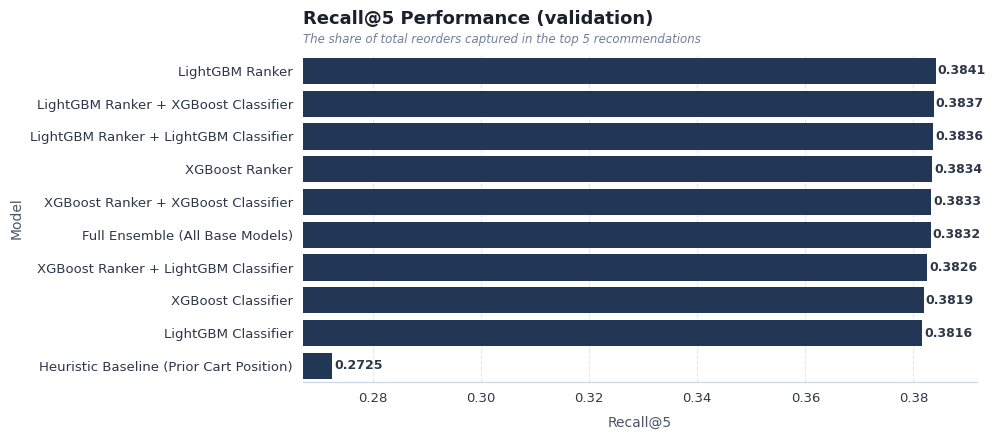

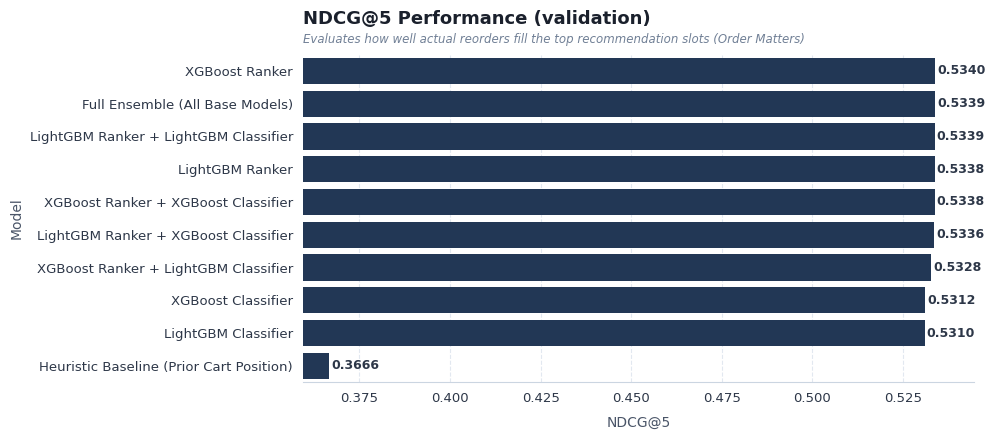

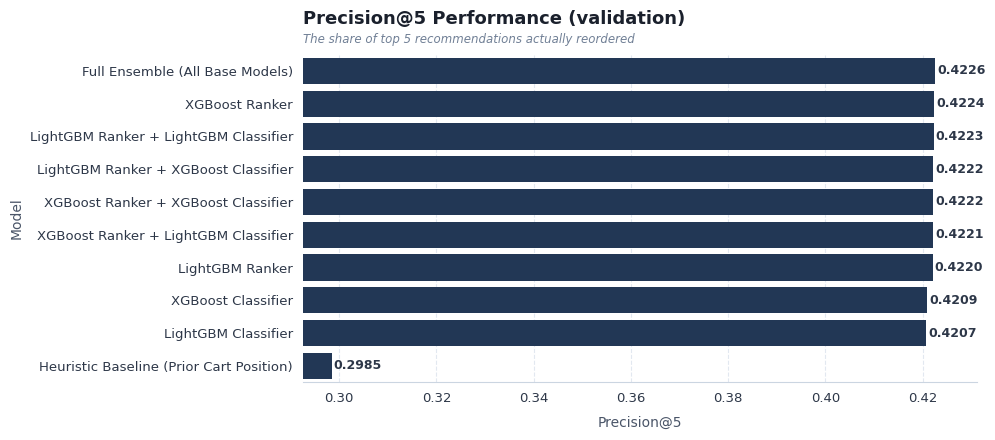

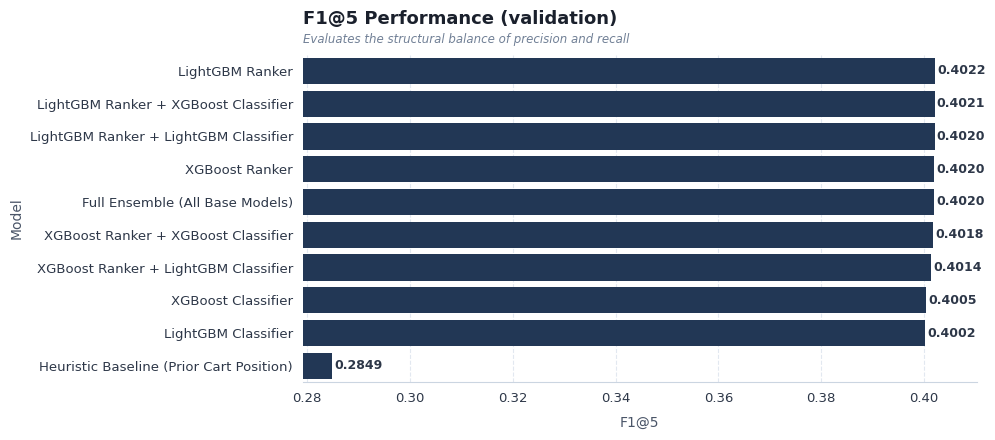

In [18]:
#Display validation evaluation metric barplots
get_barplots(val_results, dataset_name="validation")

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ol class="modern-list"> 
        <li>The XGBOOST Ranker & LightGBM Classifier ensemble is the champion model based on recall@5. On the validation split, it is the best performing model based on all evaluation metrics (recall@5, NDCG@5, precision@5, and F1@5).</li>
        <li>Given the champion model, it is not surprising that the XGBOOST Ranker model is the best performing base model (performing nearly the same as the champion model) .</li>
        <li>It is interesting to note that the XGBoost Classifier perfromed better than the LightGBM classifier, yet the ensemble of the XGBoost Ranker
            and LGBM Classifier outperformed the XGBoost Ranker & XGBOOST Classifier ensemble on the validation data </li>
</div></ol>

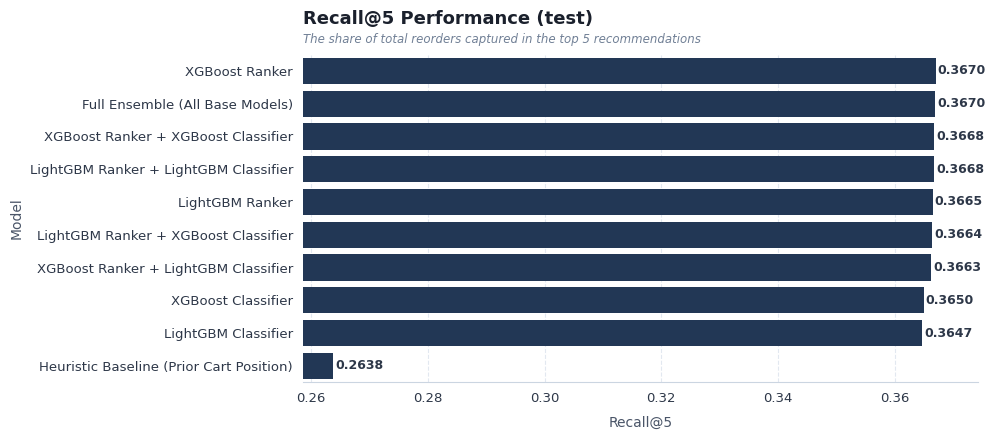

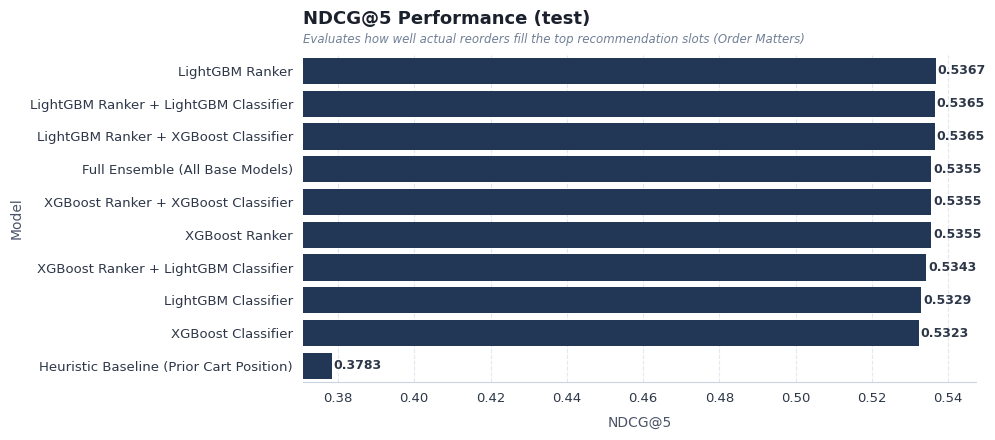

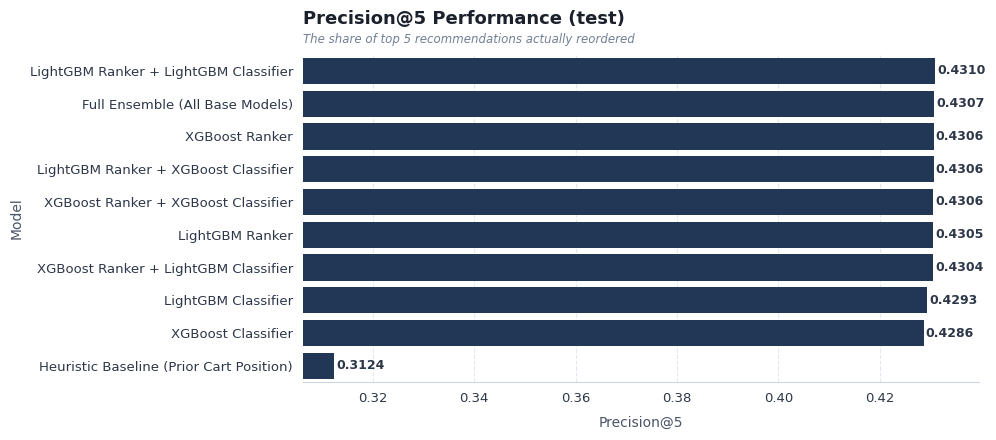

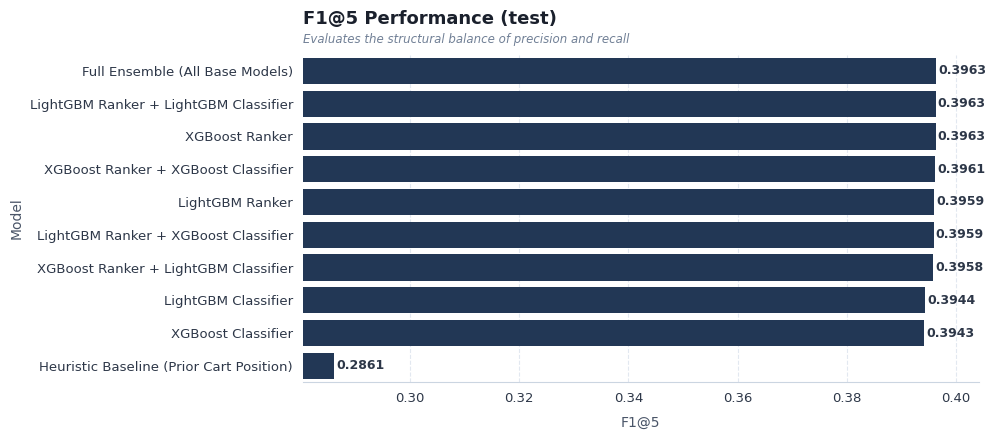

In [19]:
#Display test evaluation metric barplots
get_barplots(test_results, dataset_name="test")

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ol class="modern-list"> 
        <li>The XGBoost Ranker & XGBoost Classifier ensemble also performed well on the test data. It finshed 3rd on the main evaluation metric (recall@5) and is near the top for all other evaluation metrics (only performing neglibly worse than the best performing models on the test data).</li>
        <li>The reality is, all models are performing very similarly and significantly better than the heuristic baseline. The difference between the best performing model and worst performing (non-baseline) model is marginal.</li>
        <li>All models performed worse (including the champion model) on the test data than validation, including the heuristic model. This suggests that the test split is harder to predict.</li>
        <li>The LightGBM Classifier outperformed the XGBOOST Classifier on the test data (marginally). </li>
</div></ol>

##### Calculate SHAP, Create Feature Importance Bar Plots & Beeswarm Plots, Save Row-Level Shap to Storage Bucket

🏁 Processing SHAP analysis for: LightGBM Ranker (validation)
cuda extension was not built during install!
⚠️ GPU Explainer unavailable for LightGBM Ranker, falling back to CPU TreeExplainer...


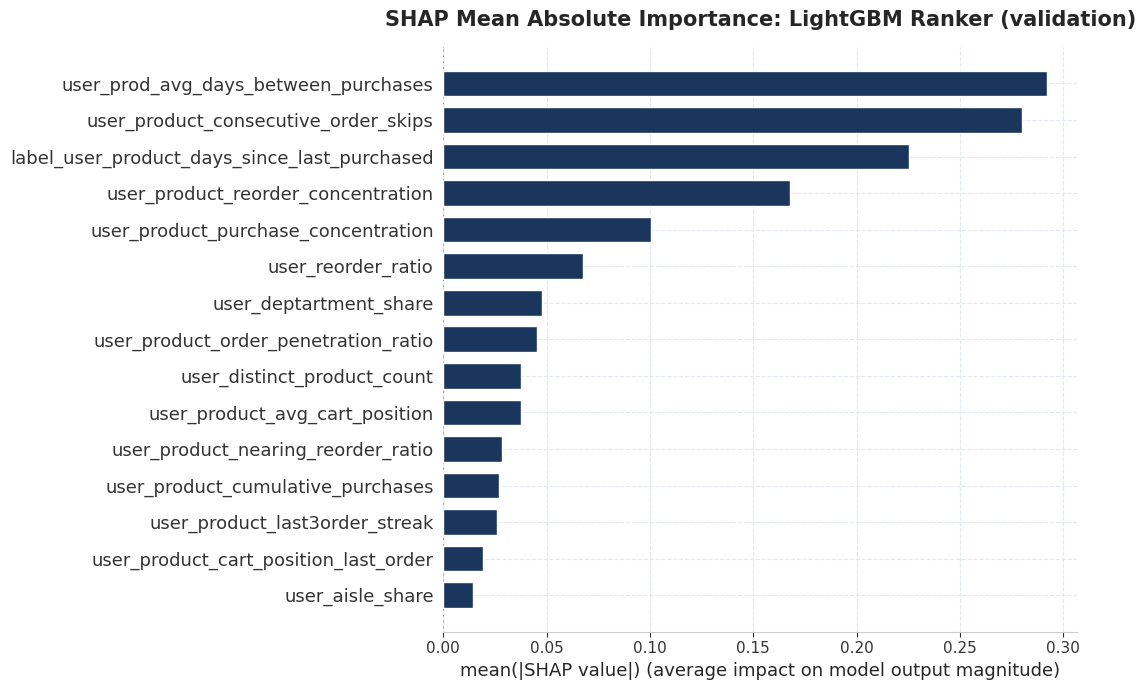

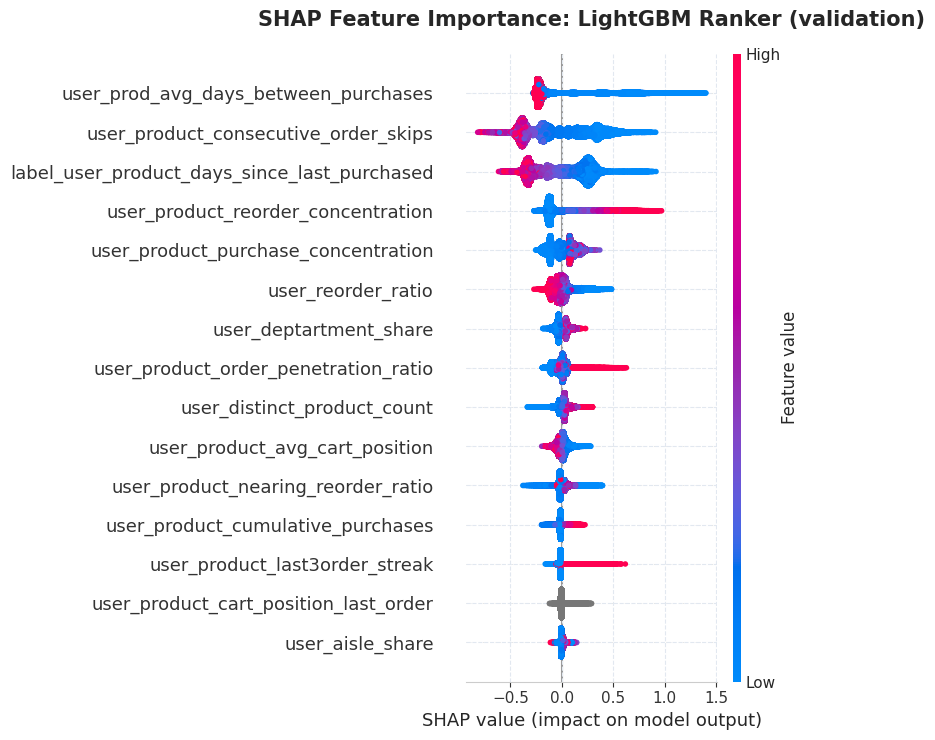

[LightGBM] [Warning] feature_fraction is set=0.7995165422145638, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7995165422145638
🚀 Streaming row-level details to BigQuery table: ml_model_results.validation_lgbm_ranker_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 11814.94it/s]


  Successfully saved 200,000 rows.
🏁 Processing SHAP analysis for: LightGBM Classifier (validation)
cuda extension was not built during install!
⚠️ GPU Explainer unavailable for LightGBM Classifier, falling back to CPU TreeExplainer...


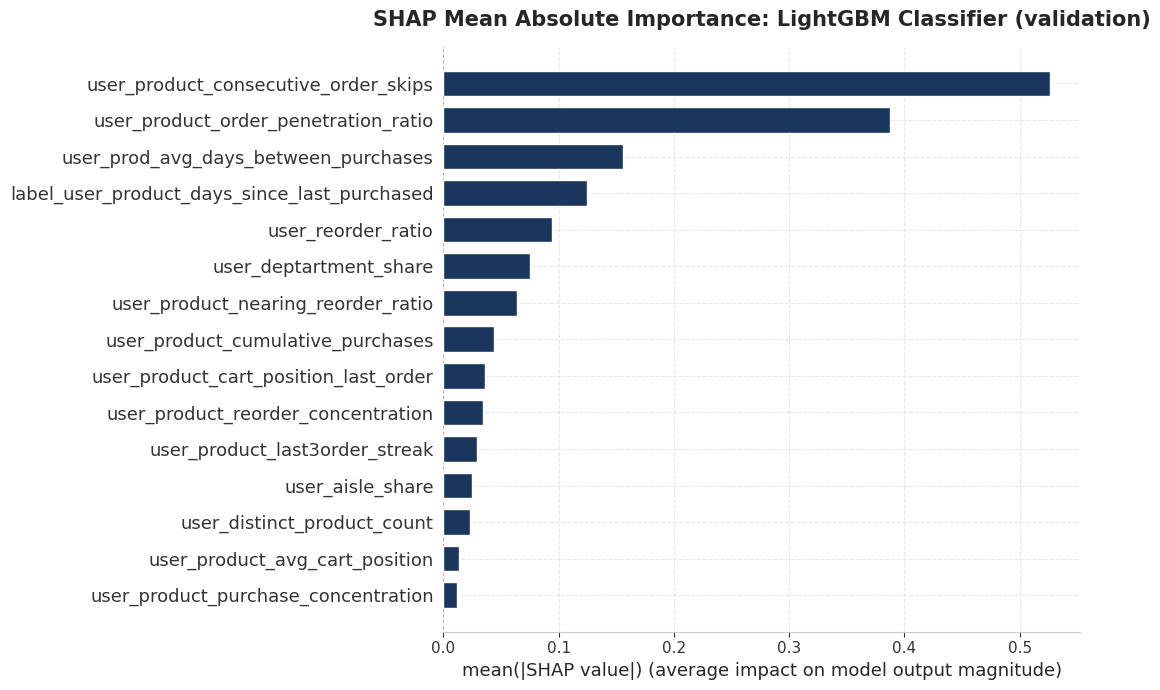

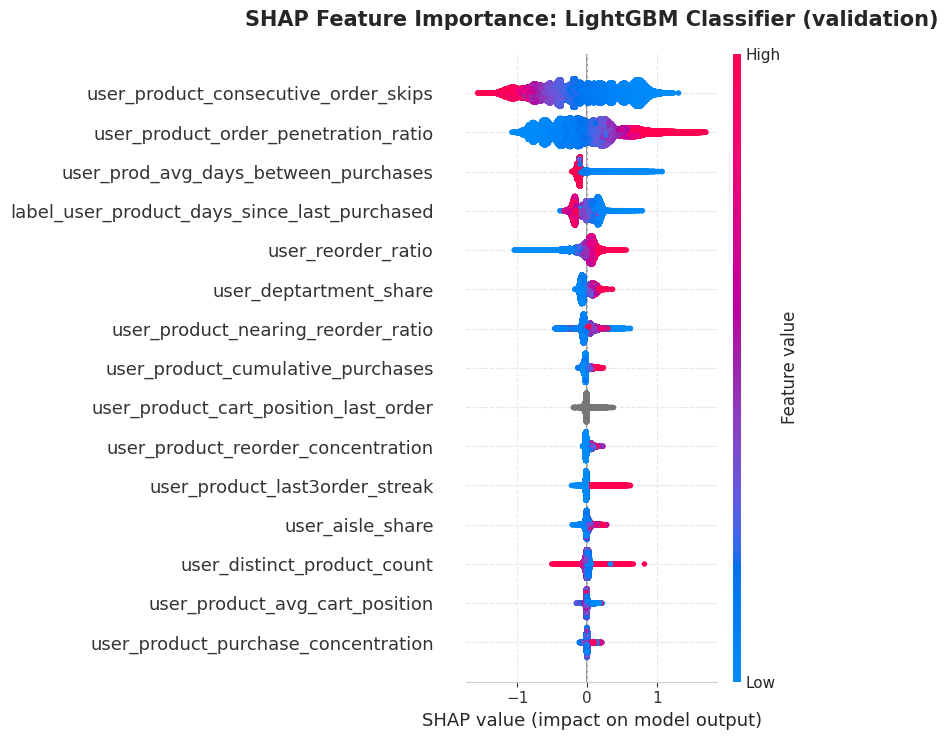

[LightGBM] [Warning] feature_fraction is set=0.6676174617581812, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6676174617581812
🚀 Streaming row-level details to BigQuery table: ml_model_results.validation_lgbm_classifier_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 12865.96it/s]


  Successfully saved 200,000 rows.
🏁 Processing SHAP analysis for: XGBoost Ranker (validation)


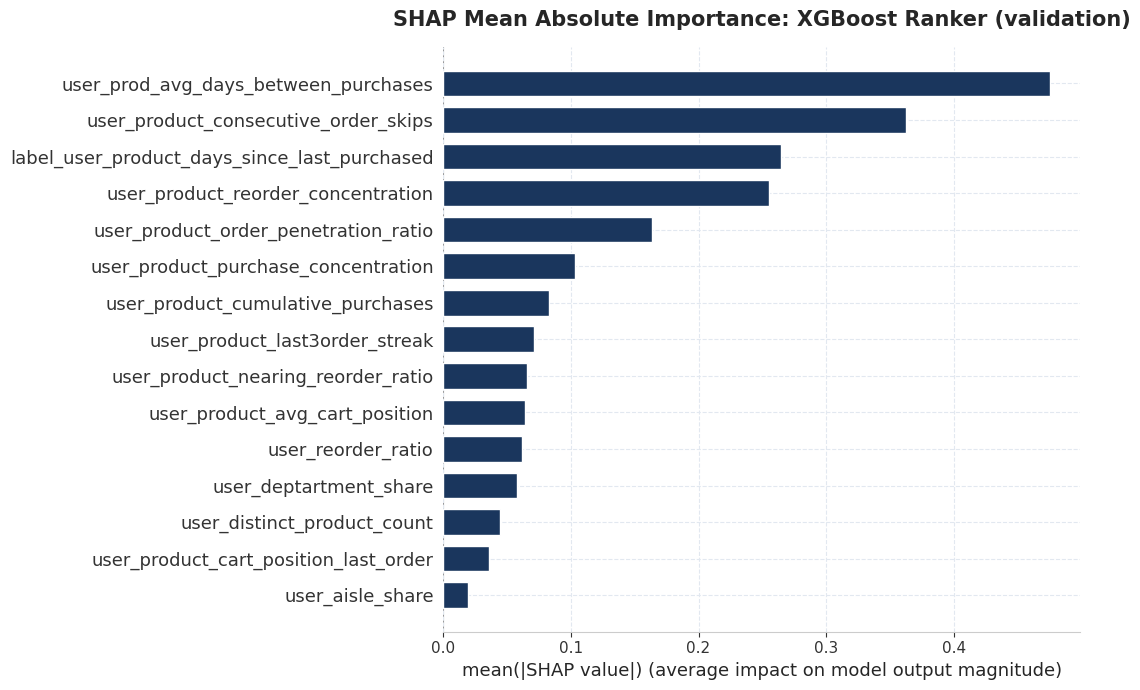

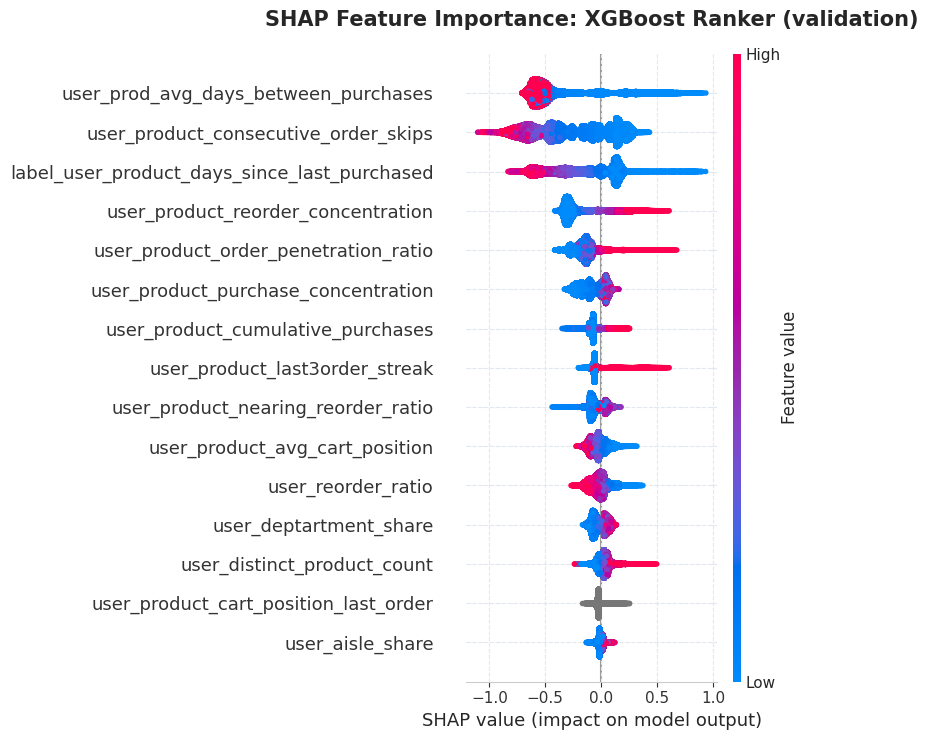

🚀 Streaming row-level details to BigQuery table: ml_model_results.validation_xgboost_ranker_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 16384.00it/s]


  Successfully saved 200,000 rows.
🏁 Processing SHAP analysis for: XGBoost Classifier (validation)


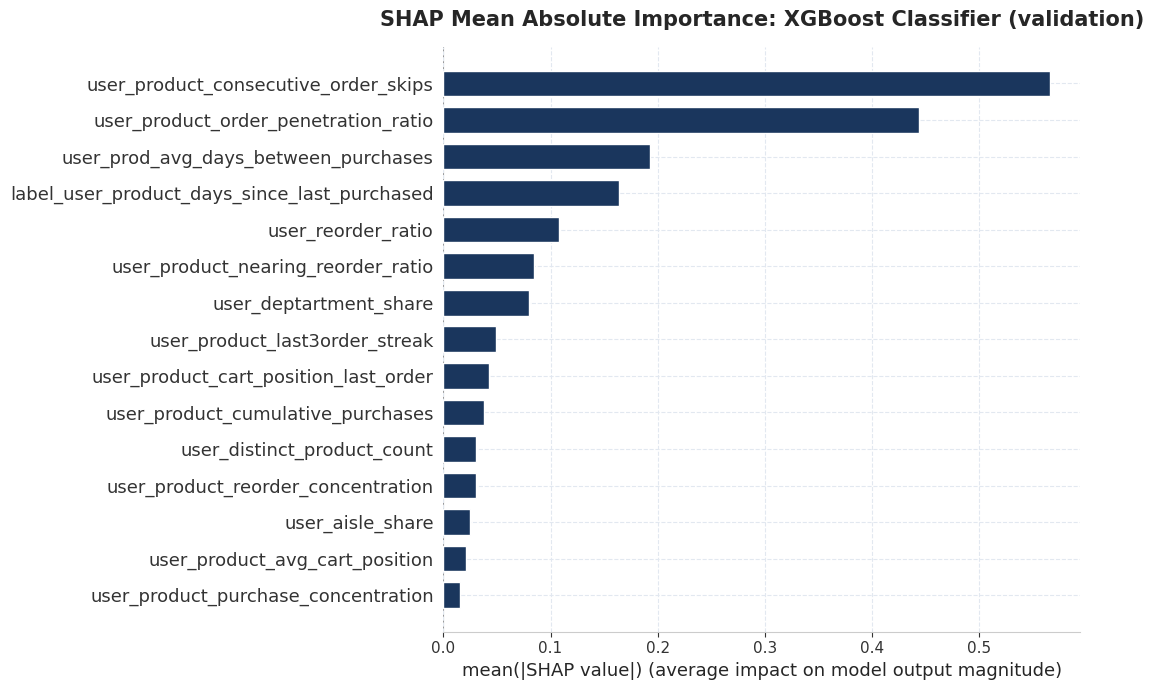

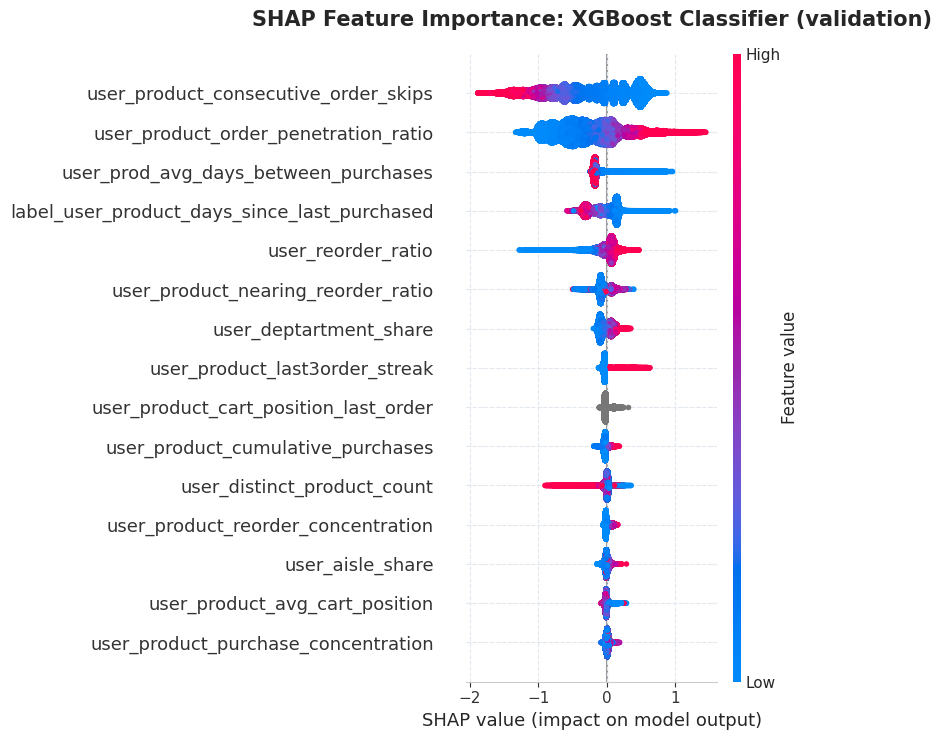

🚀 Streaming row-level details to BigQuery table: ml_model_results.validation_xgboost_classifier_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 12748.64it/s]

  Successfully saved 200,000 rows.


In [20]:
#Validation
val_power_bi_shap_barplots= get_shap_plots(models, val_df, feature_list, project_id, model_mapping, feature_display_mapping, dataset_split='validation', sample_size=200000)

🏁 Processing SHAP analysis for: LightGBM Ranker (test)
cuda extension was not built during install!
⚠️ GPU Explainer unavailable for LightGBM Ranker, falling back to CPU TreeExplainer...


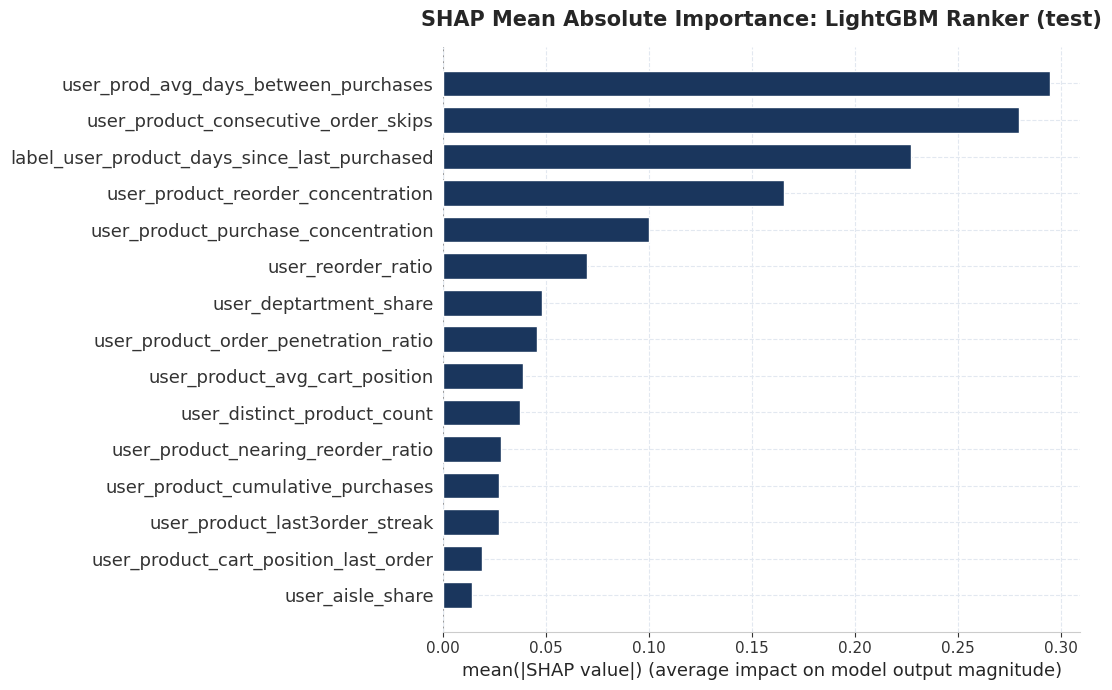

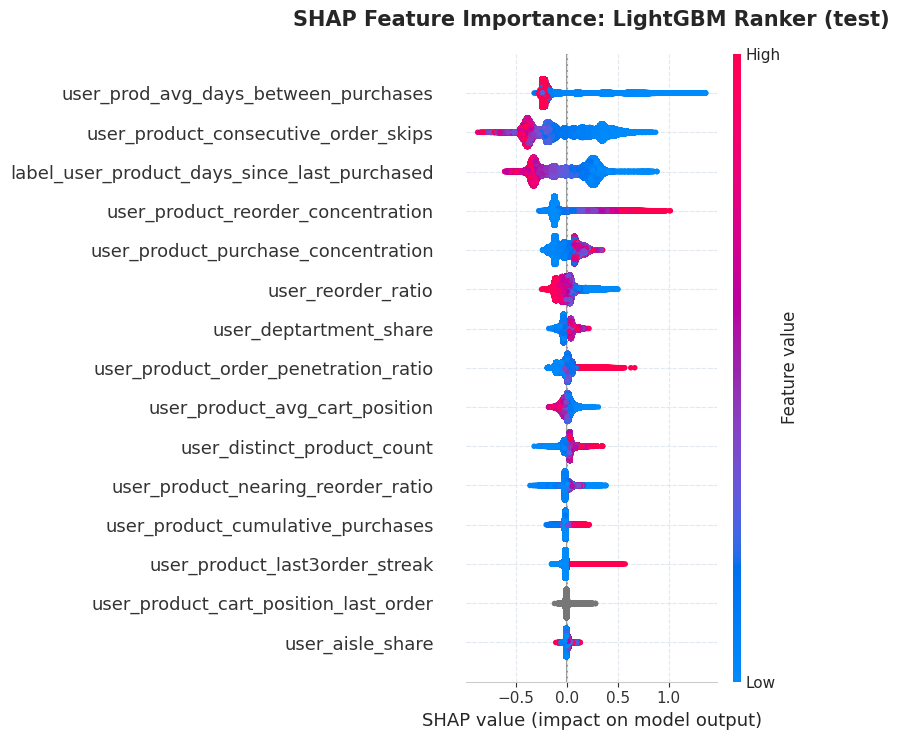

[LightGBM] [Warning] feature_fraction is set=0.7995165422145638, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7995165422145638
🚀 Streaming row-level details to BigQuery table: ml_model_results.test_lgbm_ranker_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 13706.88it/s]


  Successfully saved 200,000 rows.
🏁 Processing SHAP analysis for: LightGBM Classifier (test)
cuda extension was not built during install!
⚠️ GPU Explainer unavailable for LightGBM Classifier, falling back to CPU TreeExplainer...


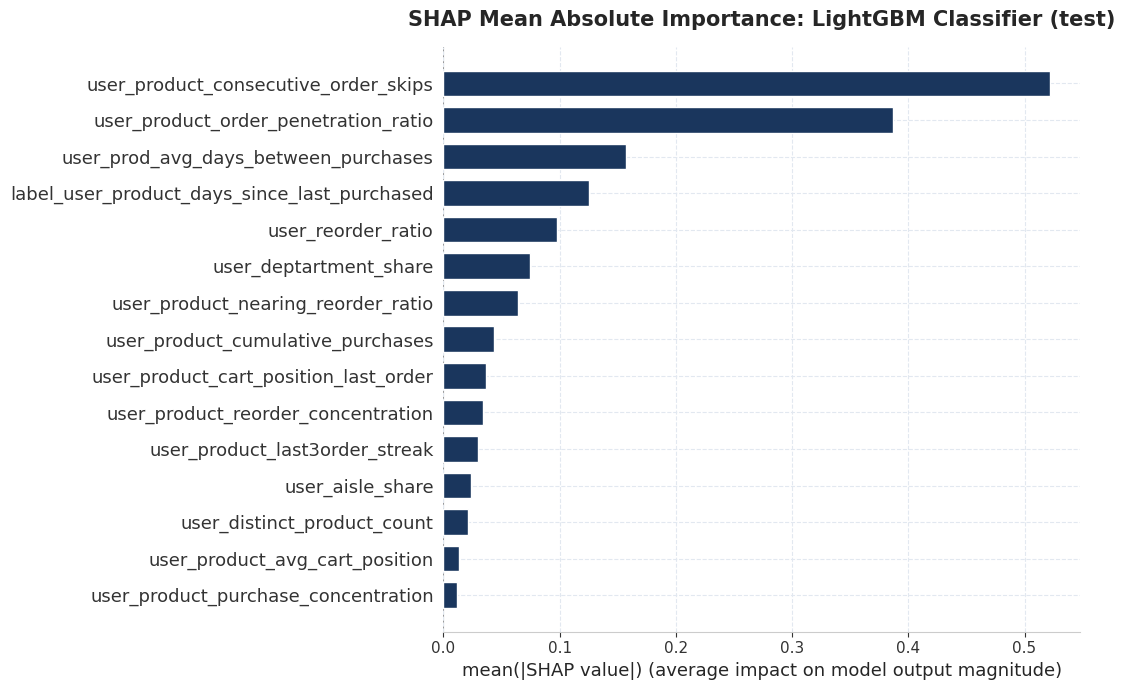

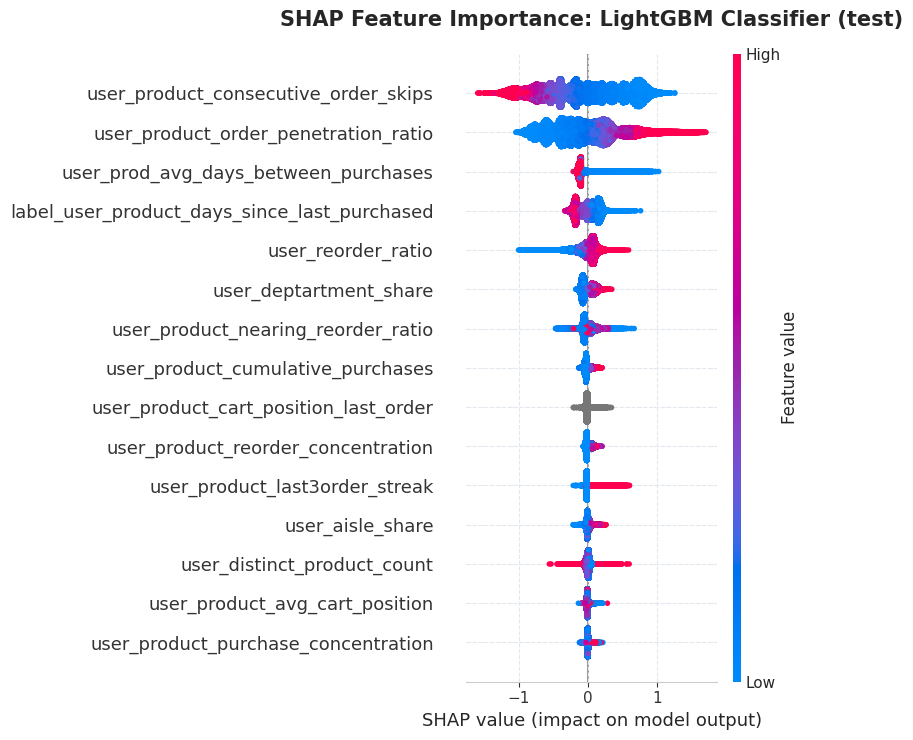

[LightGBM] [Warning] feature_fraction is set=0.6676174617581812, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6676174617581812
🚀 Streaming row-level details to BigQuery table: ml_model_results.test_lgbm_classifier_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 15887.52it/s]


  Successfully saved 200,000 rows.
🏁 Processing SHAP analysis for: XGBoost Ranker (test)


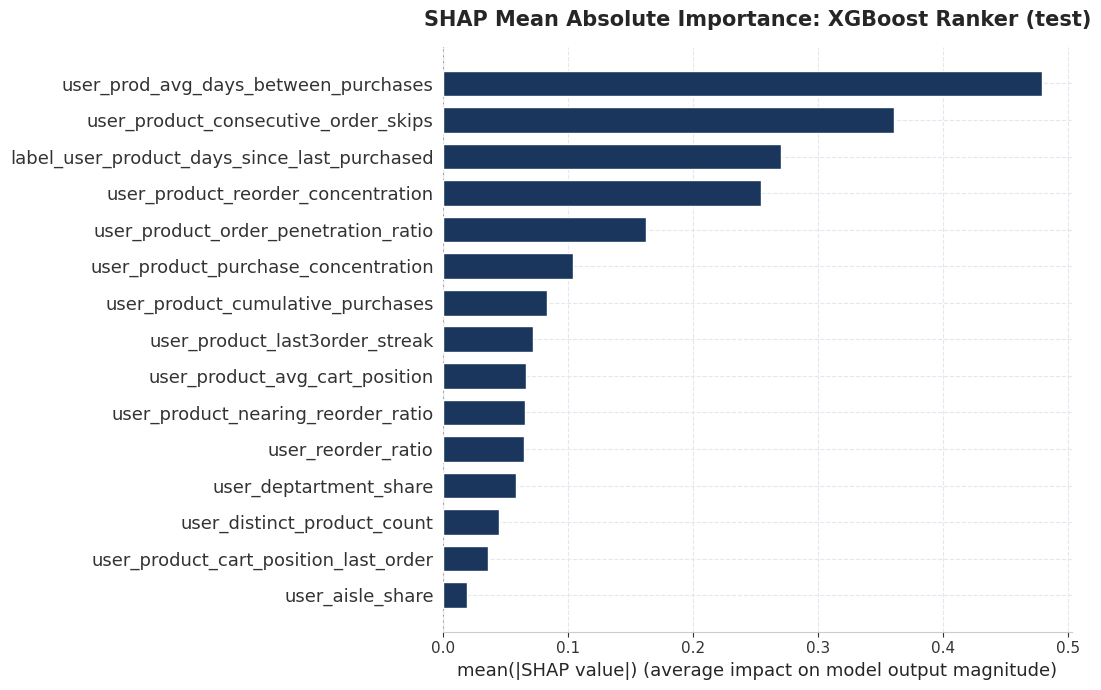

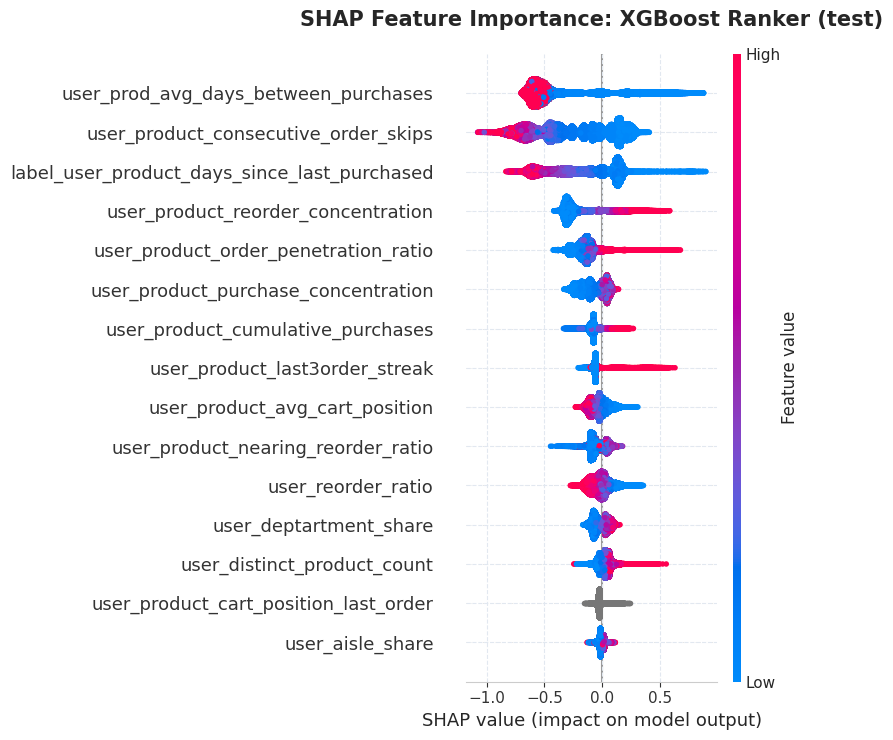

🚀 Streaming row-level details to BigQuery table: ml_model_results.test_xgboost_ranker_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 15709.00it/s]


  Successfully saved 200,000 rows.
🏁 Processing SHAP analysis for: XGBoost Classifier (test)


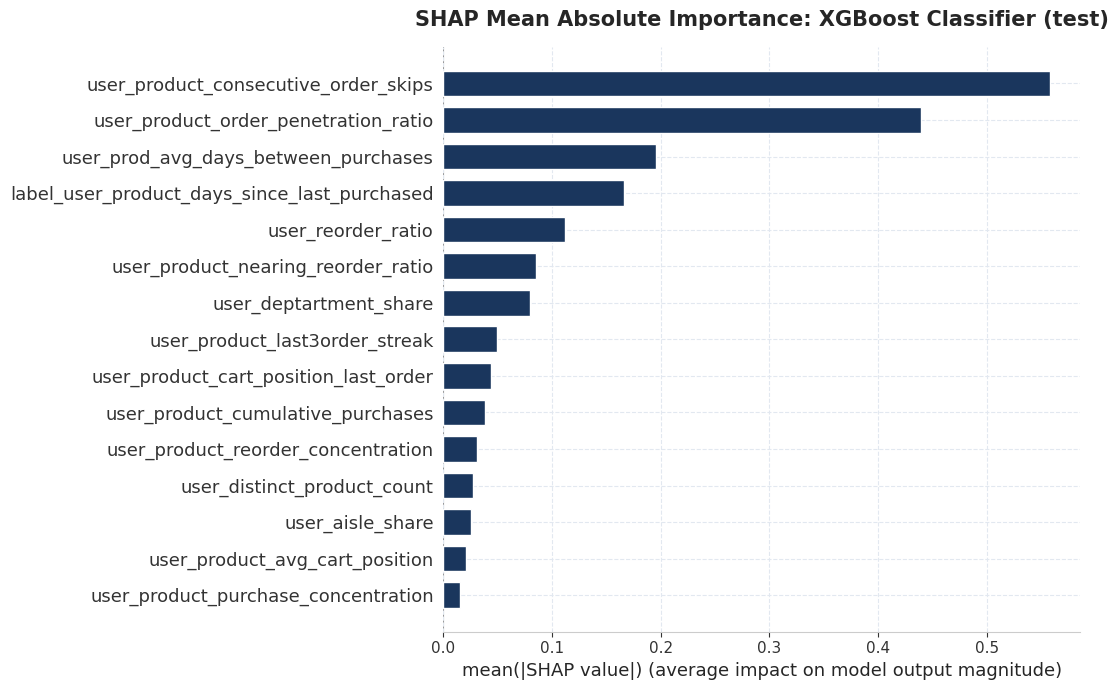

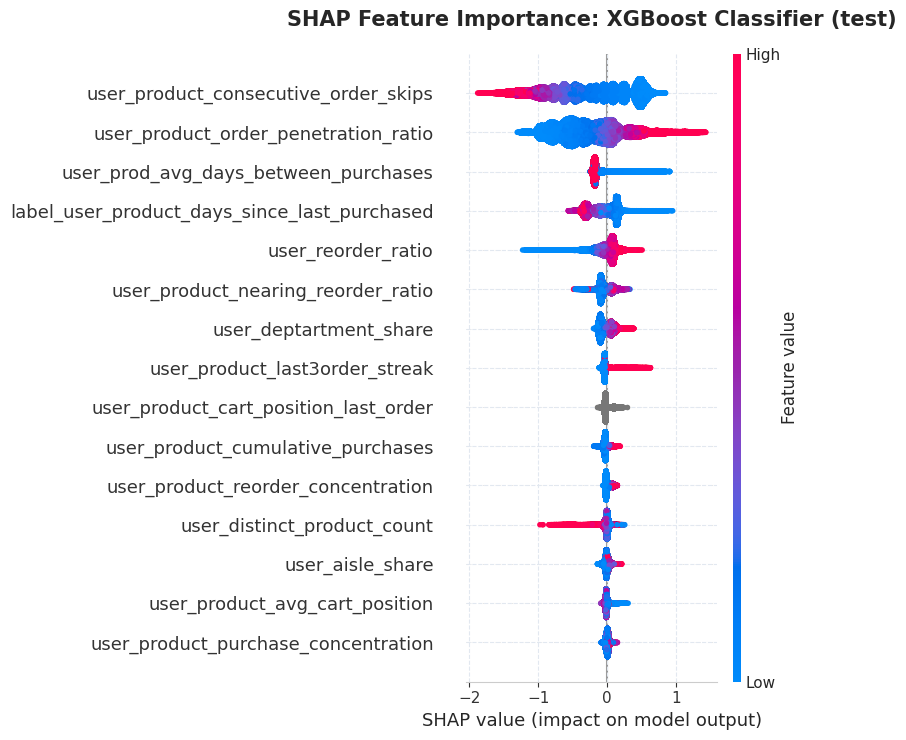

🚀 Streaming row-level details to BigQuery table: ml_model_results.test_xgboost_classifier_base_model_row_level_shap...


100%|██████████| 1/1 [00:00<00:00, 14266.34it/s]


  Successfully saved 200,000 rows.


In [21]:
#Test
test_power_bi_shap_barplots= get_shap_plots(models, test_df, feature_list, project_id, model_mapping, feature_display_mapping, dataset_split='test', sample_size=200000)

<div style="background-color: #e6f4ea; border-left: 4px solid #137333; color: #137333; padding: 15px; border-radius: 4px; margin: 15px 0;">
    <strong>💡 Key Insights:</strong> 
    <ol class="modern-list"> 
        <li>Feature importance and direction shown in the bar & beeswarm plots align with expecations providing further confidence in model results.</li>
        <li>Just as seen in the base model in the eda & feature screening notebook, predictions are largley driven by timing metrics (like average days between purchases combined with days since last purchase), streak related features (consecutive order skips) and the concentration and penetration ratios</li>
</div></ol>

In [22]:
# Concat val and test Power BI SHAP barplot data
power_bi_shap_barplots = pd.concat([val_power_bi_shap_barplots, test_power_bi_shap_barplots], ignore_index=True)

#Add Model Model Type Column for Power BI Slicer
power_bi_shap_barplots['model_type'] = np.where( power_bi_shap_barplots['model_id'].str.contains('lgbm', case=False, na=False), 'LightGBM', 'XGBoost')

##### Get Data for Power BI Beeswarm Plots

In [23]:
# 1. Create beeswarm plot data

#Validation
val_beeswarm_plot_data = sample_power_bi_beeswarm_data(models, 'validation', project_id, feature_list, model_mapping, feature_display_mapping, rows_per_feature=600)

#Test
test_beeswarm_plot_data = sample_power_bi_beeswarm_data(models, 'test', project_id, feature_list, model_mapping, feature_display_mapping, rows_per_feature=600)

#Combined
beeswarm_plot_data = pd.concat([val_beeswarm_plot_data, test_beeswarm_plot_data], ignore_index=True)

# 2. Get Model Type & Normalized Feature Value
#Add Model Model Type Column for Power BI Slicer
beeswarm_plot_data['model_type'] = np.where( beeswarm_plot_data['model_id'].str.contains('lgbm', case=False, na=False), 'LightGBM', 'XGBoost')

#Normalize feature value between 0 and 1 to use for Power BI color gradient
beeswarm_plot_data['feature_value_normalized'] = beeswarm_plot_data.groupby(['model_name', 'split', 'feature_name'])['feature_value'].transform(lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0)

# 3. Merge Mean Absolute SHAP from bar plot output & create Feature importance rank
beeswarm_plot_data = pd.merge(beeswarm_plot_data, power_bi_shap_barplots[['model_name', 'split', 'feature_name', 'mean_absolute_shap']], 
    on=['model_name', 'split', 'feature_name'], how='left')

# Create Feature Importance Rank
beeswarm_plot_data['feature_importance_rank'] = (beeswarm_plot_data.groupby(['model_name', 'split'])['mean_absolute_shap'].rank(method='dense', ascending=True))

#Add unique ID for each feature name for Power BI scatter plot y-axis
beeswarm_plot_data['feature_unique_id'] = beeswarm_plot_data.groupby(['model_name', 'split', 'feature_name']).ngroup() % beeswarm_plot_data['feature_name'].nunique()

📖 Pulling row-level metrics for LightGBM Ranker via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for LightGBM Classifier via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for XGBoost Ranker via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for XGBoost Classifier via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for LightGBM Ranker via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for LightGBM Classifier via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for XGBoost Ranker via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...
📖 Pulling row-level metrics for XGBoost Classifier via BigFrames...


🔄 Melting dataframe into long-form
🎯 Running Stratified Sampling (600 rows per feature)...


##### Save Power BI Dashboard Data to Big Query & Validation Results and Test Results to Storage

In [24]:
# 1. SAVE MODEL EVALUATION METRICS DATA

#Replace '@' with '_at_' in all column names to satisfy BigQuery schema requirements
combined_results.columns = combined_results.columns.str.replace('@', '_at_', regex=False)

combined_results.to_gbq(destination_table= f'{results_dataset}.evaluation_metrics', project_id= project_id, if_exists='replace')

print(f"  combined_results: Successfully saved {len(combined_results):,} rows to big query.")

# 2. SAVE SHAP BARPLOT DATA

power_bi_shap_barplots.to_gbq(destination_table=f'{results_dataset}.power_bi_shap_barplots', project_id=project_id, if_exists='replace')

print(f"  power_bi_shap_barplots: Successfully saved {len(power_bi_shap_barplots):,} rows to big query.")

# 3. SAVE BEESWARM PLOT DATA

beeswarm_plot_data.to_gbq(destination_table= f'{results_dataset}.beeswarm_plot_data', project_id= project_id, if_exists='replace')

print(f"  beeswarm_plot_data: Successfully saved {len(beeswarm_plot_data):,} rows to big query.")

# 4. SAVE OPTIMAL ENSEMBLE WEIGHTS

optimal_ensemble_weights = get_optimal_weights_powerbi_pie_chart(optimal_weights, model_mapping)

optimal_ensemble_weights.to_gbq(destination_table= f'{results_dataset}.optimal_ensemble_weights', project_id= project_id, if_exists='replace')

print(f"  optimal_ensemble_weights: Successfully saved {len(optimal_ensemble_weights):,} rows to big query.")

# 5. SAVE DIMENSION TABLES

#Create Dimension Tables
models_dimension = pd.DataFrame(combined_results['Model'].unique(), columns= ['Model'])
base_models_dimension = pd.DataFrame(power_bi_shap_barplots['model_name'].unique(), columns= ['model_name'])
model_types_dimension = pd.DataFrame(beeswarm_plot_data['model_type'].unique(), columns= ['model_type'])
dataset_split_dimension = pd.DataFrame(combined_results['Split'].unique(), columns= ['dataset_split'])

#Save to Big Query
models_dimension.to_gbq(destination_table= f'{results_dataset}.models_dimension', project_id= project_id, if_exists='replace')
print(f"  models_dimension: Successfully saved {len(models_dimension):,} rows to big query.")

base_models_dimension.to_gbq(destination_table= f'{results_dataset}.base_models_dimension', project_id= project_id, if_exists='replace')
print(f"  base_models_dimension: Successfully saved {len(base_models_dimension):,} rows to big query.")

model_types_dimension.to_gbq(destination_table= f'{results_dataset}.model_types_dimension', project_id= project_id, if_exists='replace')
print(f"  model_types_dimension: Successfully saved {len(model_types_dimension):,} rows to big query.")

dataset_split_dimension.to_gbq(destination_table= f'{results_dataset}.dataset_split_dimension', project_id= project_id, if_exists='replace')
print(f"  dataset_split_dimension: Successfully saved {len(dataset_split_dimension):,} rows to big query.")

# 6. SAVE VALIDATION AND TEST RESULTS TO STORAGE

val_results.to_parquet(f"gs://{BUCKET_NAME}/evaluation_results/val_results.parquet", index=False)
print(f"  val_results: Successfully saved {len(val_results):,} rows to storage.")

test_results.to_parquet(f"gs://{BUCKET_NAME}/evaluation_results/test_results.parquet", index=False)
print(f"  test_results: Successfully saved {len(test_results):,} rows to storage.")

100%|██████████| 1/1 [00:00<00:00, 15363.75it/s]


  combined_results: Successfully saved 20 rows to big query.


100%|██████████| 1/1 [00:00<00:00, 16070.13it/s]


  power_bi_shap_barplots: Successfully saved 120 rows to big query.


100%|██████████| 1/1 [00:00<00:00, 15307.68it/s]


...

  base_models_dimension: Successfully saved 4 rows to big query.


100%|██████████| 1/1 [00:00<00:00, 14463.12it/s]


  model_types_dimension: Successfully saved 2 rows to big query.


100%|██████████| 1/1 [00:00<00:00, 15709.00it/s]


  dataset_split_dimension: Successfully saved 2 rows to big query.
  val_results: Successfully saved 10 rows to storage.
  test_results: Successfully saved 10 rows to storage.
